In [278]:
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor, Pool
from shared.model_params import shift, lag_size, n_clusters

In [279]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.base import TransformerMixin, BaseEstimator, RegressorMixin
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [280]:
class DataLoader:
    def __init__(self, countries, max_count = (0, 5), shift_size = 4, lag_size = 6, logging = True):
        self.countries = countries
        self.max_count = max_count
        self.shift_size = shift_size
        self.lag_size = lag_size
        self.logging = logging

    def get_datasets(self, folder_path):
        all_x = []
        all_y = []
        
        for country in self.countries:
            for count in range(*self.max_count):
                path = folder_path + f"{country}_{count}.csv"
                try:
                    df = pd.read_csv(path)
                    target = df["gdp"].ffill().bfill().shift(-self.shift_size).dropna()
                    features = df.iloc[:len(target)].copy()
                    all_x.append(features)
                    all_y.extend(target.tolist())
                except Exception as e:
                    if self.logging:
                        print(f"Ошибка в {path}: {e}")
        data = pd.concat(all_x, ignore_index=True)
        data["war_status"] = data["war_status"].astype(int)
        
        return data, np.array(all_y)
    
    def prepare_target(self, y):
        return np.log1p(y)
    
    
    @staticmethod
    def _generate_period_names(data):
        bins = [0, 1850, 1862, 1873, 1885, 1895, 1906, np.inf]
        labels = [
            '1836-1850',
            '1851-1862', 
            '1863-1873', 
            '1874-1885', 
            '1886-1895', 
            '1896-1906', 
            '1907+'
        ]
        year = pd.to_datetime(data["date"]).dt.year
        name = data["flag_name"].str.split("_").str[0]
        periods = pd.cut(year, bins=bins, labels=labels)
        return name + " (" + periods.astype(str) + ")"

    
    def add_name(self, data):
        data["name"] = self._generate_period_names(data)
        return data

    def add_new_cols(self, arr):
        res = []
        for col in arr:
            for i in range(1, self.lag_size + 1):
                res.append(f"{col}_log_diff_{i}")
            res.append(f"{col}_rolling_mean_3")
            res.append(f"{col}_rolling_std_5")
        return res

In [281]:
class DataProcessor(BaseEstimator, TransformerMixin):
    def __init__(self, num_cols, important_cols, lag_size):
        self.num_cols = num_cols
        self.important_cols = important_cols
        self.lag_size = lag_size

    def fit(self, X, y=None):
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X = X.copy()
        new_cols = {}
        X["gdp"] = X["gdp"].bfill().ffill()
        X["gdp"] = np.log1p(X["gdp"])
        X["tax_progressivity"] = X["rich_tax"] - X["poor_tax"]
        X["innovation_total"] = X["prom_innov"] + X["comm_innov"]
        for col in self.num_cols:
            X[col] = X[col].bfill().ffill().astype(float)
        for col in self.important_cols:
            for i in range(1, self.lag_size + 1):
                new_cols[f"{col}_log_diff_{i}"] = np.log1p(X[col]).diff(i)
            new_cols[f"{col}_rolling_mean_3"] = X[col].rolling(3).mean()
            new_cols[f"{col}_rolling_std_5"] = X[col].rolling(5).std()
        X = pd.concat([X, pd.DataFrame(new_cols, index=X.index)], axis=1)
        return X.ffill().bfill()
    
class DataSelector(BaseEstimator, TransformerMixin):
    def __init__(self, all_cols):
        self.all_cols = all_cols
    
    def fit(self, X, y = None):
        return self
    
    def transform(self, X):
        return X[self.all_cols]
    

class ClusterPredictor(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=5, features_for_clustering=None):
        self.n_clusters = n_clusters
        self.features_for_clustering = features_for_clustering
        self.scaler = StandardScaler()
        self.kmeans = KMeans(n_clusters=self.n_clusters, random_state=42, n_init=10)

    def fit(self, X, y=None):
        x_subset = X[self.features_for_clustering]
        x_scaled = self.scaler.fit_transform(x_subset)
        self.kmeans.fit(x_scaled)
        return self

    def transform(self, X):
        X = X.copy()
        x_subset = X[self.features_for_clustering]
        x_scaled = self.scaler.transform(x_subset)
        X["cluster"] = self.kmeans.predict(x_scaled)
        X["cluster"] = X["cluster"].astype(str)
        return X

    def get_scaler(self):
        return self.scaler

In [282]:
loader = DataLoader(["ENG", "USA", "RUS", "AUS", "CHI", "BEL", "PRU", "SWE", "FRA", "ETH", "TUR", "SIC", "MEX", "BRZ", "AFG", "PER", "POR"], (1, 6), shift_size=shift, lag_size=lag_size, logging=False)

In [283]:
cat_cols = ["most_popular_party", "war_status", "cluster"]
num_cols = ["gdp", "money_activity", "subside_percent", "rentability", "diversification", "gdp_per_cap", "gdp_per_reg",\
             "country_savings", "bank_savings", "population_savings", "money_mass", "all_employemenent", "all_free_work_places", "fabric_worker_salary",\
             "capitalist_salary", "literacy", "military_budget", "naval_budget", "army_innov", "naval_innov", "country_size", "population_per_reg",\
             "rich_tax", "middle_tax", "poor_tax", "prom_innov", "comm_innov", "tax_progressivity", "innovation_total"]

important_cols = ["gdp", "poor_tax", "bank_savings", "population"]
new_num_cols = loader.add_new_cols(important_cols)
deleted_cols = ["industrial_level", "subside_pct", "gold_income", "goverement"]
all_cols = cat_cols + num_cols + new_num_cols
cluster_cols = ["gdp", "population", "money_activity", "rentability", "diversification", "literacy", "prom_innov", "comm_innov", "innovation_total", "rich_tax", "middle_tax", "poor_tax", "tax_progressivity",\
                "gdp_log_diff_1", "bank_savings_log_diff_1", "population_log_diff_1", "bank_savings"]

In [284]:
data, y = loader.get_datasets("data/")
y = loader.prepare_target(y)

In [285]:
pipe = Pipeline([
    ("Data_prepare", DataProcessor(num_cols, important_cols, lag_size=lag_size)),
    ("Clusterisation", ClusterPredictor(n_clusters=10, features_for_clustering=cluster_cols)),
    ("Data_select", DataSelector(all_cols)),
    ("Model", CatBoostRegressor(
        iterations=800,
        learning_rate=0.05,
        loss_function="MAE",
        l2_leaf_reg=20,
        has_time=True,
        depth=8,
        verbose=100,
        cat_features=cat_cols
    ))
])

In [286]:
pipe.fit(data, y)

0:	learn: 1.2722443	total: 78.1ms	remaining: 1m 2s
100:	learn: 0.1588773	total: 7.22s	remaining: 50s
200:	learn: 0.1278152	total: 14.1s	remaining: 42s
300:	learn: 0.1058361	total: 21.1s	remaining: 34.9s
400:	learn: 0.0914411	total: 27.2s	remaining: 27.1s
500:	learn: 0.0817884	total: 33.9s	remaining: 20.2s
600:	learn: 0.0738003	total: 40.1s	remaining: 13.3s
700:	learn: 0.0672731	total: 46s	remaining: 6.5s
799:	learn: 0.0620911	total: 51.9s	remaining: 0us


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Data_prepare', ...), ('Clusterisation', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,num_cols,"['gdp', 'money_activity', ...]"
,important_cols,"['gdp', 'poor_tax', ...]"
,lag_size,12
,n_clusters,10
,features_for_clustering,"['gdp', 'population', ...]"
,all_cols,"['most_popular_party', 'war_status', ...]"


In [287]:
test_loader = DataLoader(["FRA"], (1, 5), shift_size=shift)
test, y_test = test_loader.get_datasets("data/")
y_test = loader.prepare_target(y_test)

In [288]:
prediction = pipe.predict(test)

In [289]:
class Stats:
    def __init__(self, pipe, data):
        self.pipe = pipe
        self.cluster = pipe.named_steps["Clusterisation"]
        self.model = pipe.named_steps["Model"]
        self.data = data

    def model_score(self):
        y_true = self.data["gdp"].ffill().bfill()
        y_pred = self.pipe.predict(self.data)
        y_pred = np.expm1(y_pred)
        print(f"MAE: {mean_absolute_error(y_true, y_pred)}")
        print(f"MSE: {mean_squared_error(y_true, y_pred)}")
        print(f"RMSE: {root_mean_squared_error(y_true, y_pred)}")
        return
    
    def get_clusters_info(self, mode = "normal", scaler: StandardScaler = None):
        '''modes:
            1. normal - вывод списка стран и кластеров
            2. percent - вывод вероятности страны попадания в конкретный кластер
            3. explain - выводит центральные нормализированные значения каждого кластера
            4. hard_explain - выводит центральные ненормализованные значения каждого кластера
            5. lite_explain - менее подробно, но красиво выводит смыслы кластеров'''
        X = loader.add_name(self.data.copy())
        X_prepared = self.pipe.named_steps["Data_prepare"].transform(X)
        X_prepared["name"] = X["name"].values
        match mode:
            case "normal":
                X_grouped = (
                    X_prepared.groupby("name")[cluster_cols]
                    .mean()
                    .reset_index()
                )
                X_clustered = self.cluster.transform(X_grouped)
                for cluster, group in X_clustered.groupby("cluster"):
                    print(f"\nCluster {int(cluster)+1} ({len(group)} элементов):")
                    for n in group["name"]:
                        print(n, end=" ")

            case "percent":
                X_clustered = self.cluster.transform(X_prepared)
                grouped_pct = (
                    X_clustered
                    .groupby("name")["cluster"]
                    .value_counts(normalize=True)
                    .unstack(fill_value=0)
                )
                print(grouped_pct)

            case "explain":
                centers = self.cluster.kmeans.cluster_centers_
                centers_df = pd.DataFrame(centers, columns=cluster_cols)
                print(centers_df)

            case "hard_explain":
                centers = self.cluster.kmeans.cluster_centers_
                centers_df = pd.DataFrame(centers, columns=cluster_cols)
                centers_df = scaler.inverse_transform(centers_df)
                print(centers_df)
            
            case "lite_explain":
                centers = self.cluster.kmeans.cluster_centers_
                centers_df = pd.DataFrame(centers, columns=cluster_cols)
                cluster_descriptions = centers_df.apply(self.describe_cluster, axis=1)
                for i, desc in enumerate(cluster_descriptions):
                    print(f"Cluster {i+1}: {desc}")
            

    def describe_cluster(self, row):
        desc = []
        if "gdp_per_cap" in row:
            if row["gdp_per_cap"] > 0.8:
                desc.append("high income")
            elif row["gdp_per_cap"] < -0.8:
                desc.append("low income")
        if row.get("population", 0) > 0.8:
            desc.append("large population")
        elif row.get("population", 0) < -0.8:
            desc.append("small population")
        if row.get("bank_savings", 0) > 1:
            desc.append("financial hub")
        elif row.get("bank_savings", 0) < -0.8:
            desc.append("low financial depth")
        if row.get("rentability", 0) > 0.5:
            desc.append("high efficiency")
        elif row.get("rentability", 0) < -0.5:
            desc.append("low efficiency")
        if row.get("literacy", 0) > 0.7:
            desc.append("high literacy")
        if row.get("prom_innov", 0) > 0.5:
            desc.append("industrialized")
        if row.get("poor_tax", 0) > 0.5:
            desc.append("redistributive")
        elif row.get("poor_tax", 0) < -0.5:
            desc.append("low redistribution")
        if any("std" in col and row[col] > 1 for col in row.index):
            desc.append("volatile")
        if not desc:
            return "mixed economy"

        return ", ".join(desc)
            
            

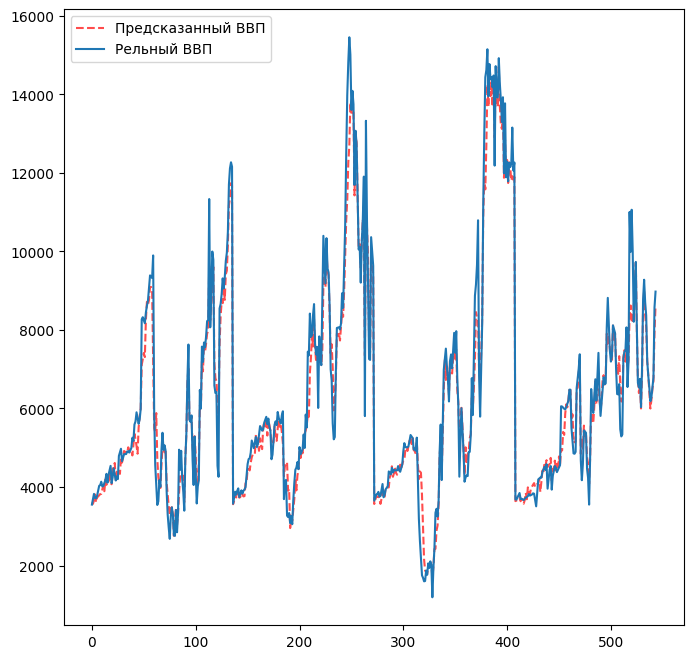

In [290]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.plot(np.expm1(prediction), "r--", label = "Предсказанный ВВП", alpha = 0.7)
plt.plot(np.expm1(y_test), label = "Рельный ВВП") 
plt.legend()
plt.show()

In [291]:
import shap

In [292]:
X_test_prepared = pipe.named_steps["Data_prepare"].transform(test)
X_test_clustered = pipe.named_steps["Clusterisation"].transform(X_test_prepared)
X_test = pipe.named_steps["Data_select"].transform(X_test_clustered)

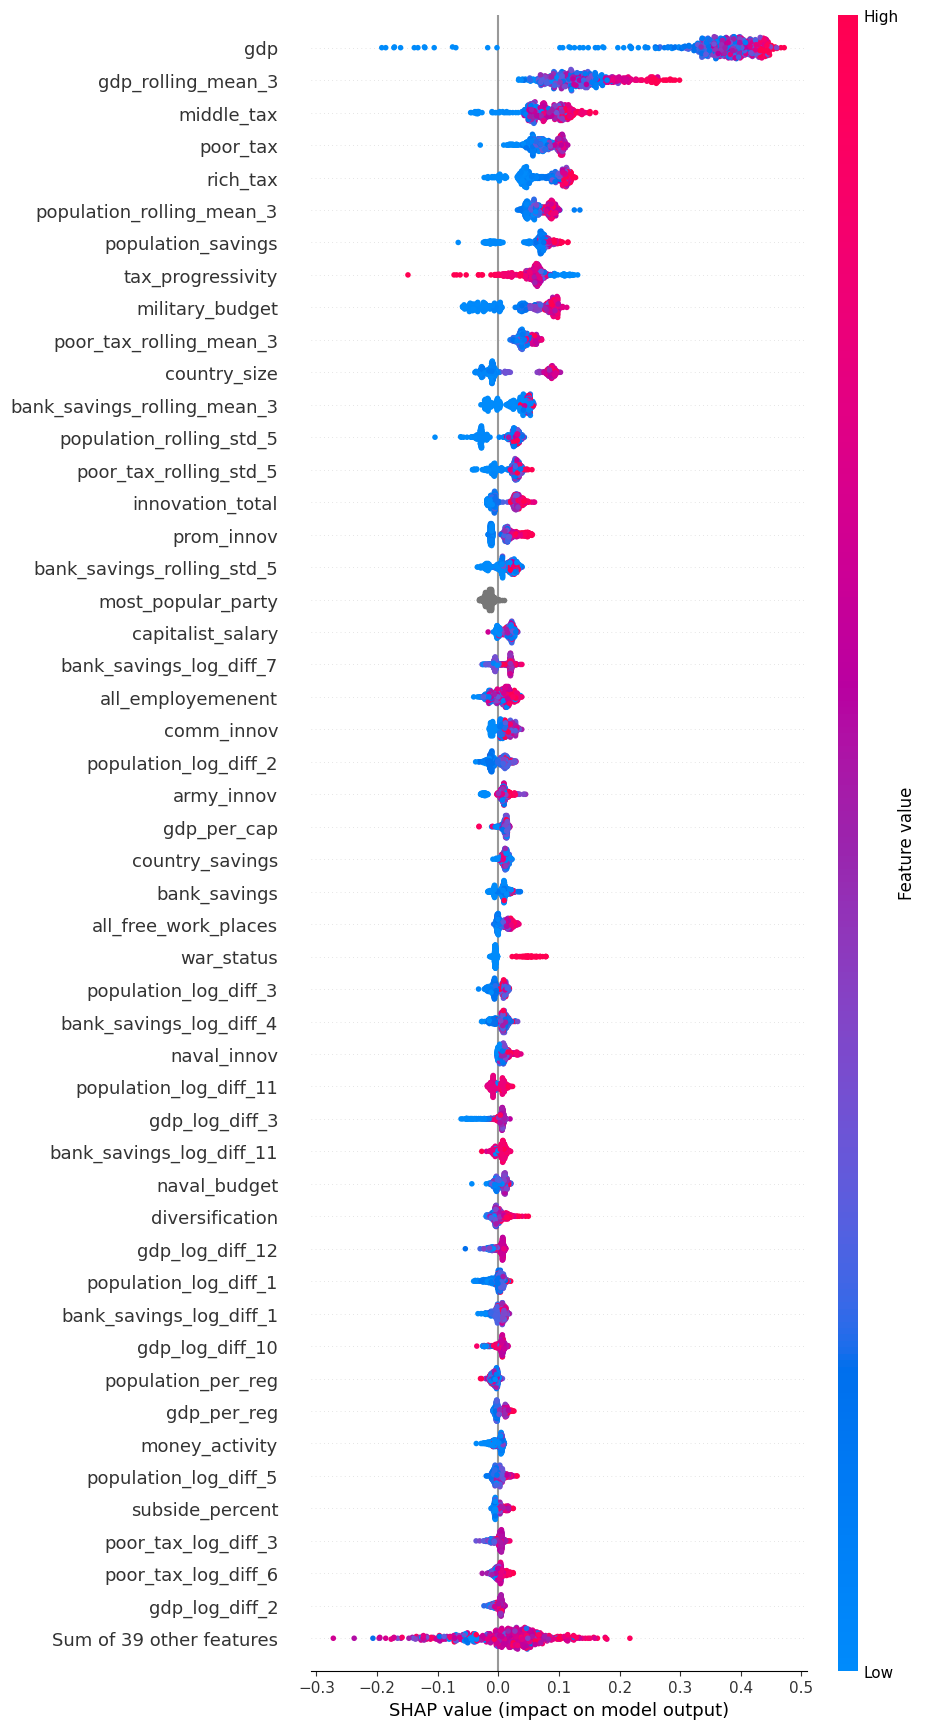

In [293]:
model = pipe.named_steps["Model"]
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)
shap.plots.beeswarm(shap_values, 50)

In [294]:
stats = Stats(pipe, data)
stats.model_score()

MAE: 476.1952178304925
MSE: 1283637.2541629162
RMSE: 1132.9771640076935


MAE: 665.1931050802222
MSE: 1876115.5031164808
RMSE: 1369.7136573446585

In [295]:
stats.get_clusters_info("lite_explain")
stats.get_clusters_info("normal")

Cluster 1: large population, redistributive
Cluster 2: low redistribution
Cluster 3: high literacy
Cluster 4: high efficiency, low redistribution
Cluster 5: low redistribution
Cluster 6: financial hub, high literacy, industrialized, redistributive
Cluster 7: mixed economy
Cluster 8: high literacy, industrialized, redistributive
Cluster 9: large population, industrialized, redistributive
Cluster 10: mixed economy

Cluster 1 (4 элементов):
ENG (1836-1850) ENG (1851-1862) ENG (1863-1873) ENG (1874-1885) 
Cluster 2 (8 элементов):
CHI (1874-1885) CHI (1886-1895) CHI (1896-1906) PER (1874-1885) PER (1886-1895) POR (1836-1850) TUR (1863-1873) TUR (1874-1885) 
Cluster 3 (29 элементов):
AUS (1874-1885) BEL (1836-1850) BEL (1851-1862) BEL (1863-1873) BEL (1874-1885) BRZ (1886-1895) BRZ (1896-1906) FRA (1836-1850) FRA (1851-1862) MEX (1886-1895) MEX (1896-1906) PER (1896-1906) POR (1896-1906) PRU (1836-1850) PRU (1851-1862) PRU (1863-1873) PRU (1874-1885) SIC (1851-1862) SIC (1863-1873) SIC (1874

In [296]:
scaler = pipe.named_steps["Clusterisation"].scaler
stats.get_clusters_info("hard_explain", scaler=scaler)

[[ 9.41859029e+00  1.66231065e+08  6.02160998e+00  9.44183673e+00
   5.64385261e+00  2.47945805e+01  2.50204082e+01  2.34149660e+01
   4.84353741e+01  9.31705756e+02  1.30928870e+03  3.82396255e+03
  -2.89225680e+03 -5.42403797e-04  2.84443295e-02  3.16029747e-03
   2.07640568e+04]
 [ 6.84592124e+00  6.04824241e+07  7.45176697e+01  7.60779817e-01
   4.81748165e+00  1.11864794e+01  1.06651376e+01  1.02798165e+01
   2.09449541e+01  1.01957607e+02  1.14309065e+02  2.81394734e+02
  -1.79437127e+02  4.47024429e-04 -5.11077299e-03  1.26119429e-03
   6.17583716e+02]
 [ 7.24432036e+00  2.21331452e+07  9.92311566e+00  1.81573564e+00
   4.03781668e+00  4.69209087e+01  2.17246263e+01  2.02612116e+01
   4.19858379e+01  1.36136048e+02  1.92146091e+02  5.69035175e+02
  -4.32899126e+02  1.29493707e-03  2.33528887e-02  5.13530548e-03
   8.90927165e+03]
 [ 6.17170060e+00  8.36008800e+06  1.23870000e+01  9.42320000e+03
   2.85300000e+00  1.56000000e+01  1.80000000e+01  1.20000000e+01
   3.00000000e+01  

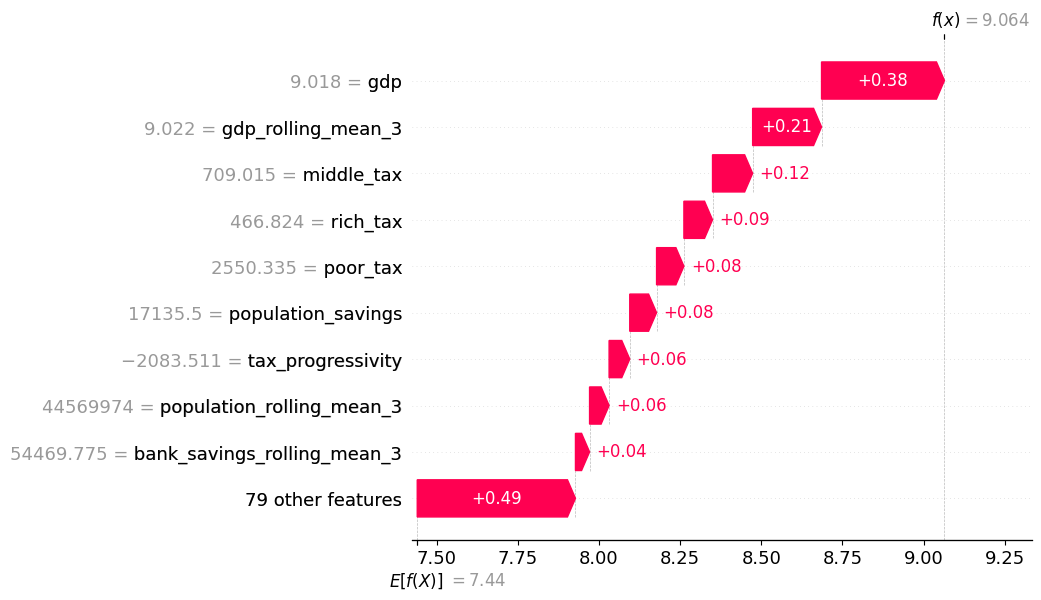

In [297]:
shap.plots.waterfall(shap_values[54])